In [1]:
import glob
import os
import sys
from pathlib import Path
import numpy as np

from scipy.interpolate import interp1d
from scipy.signal import correlate, correlation_lags
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

# from fitburst.analysis.model import SpectrumModeler
import RMtools_1D
import subprocess

from astropy.constants import c
import astropy.units as u
from astropy.time import Time
import chime_frb_constants as constants

import baseband
from baseband import vdif
from baseband_tasks.shaping import Transpose, Reshape
from baseband_tasks.combining import Concatenate
from baseband_tasks.functions import Square, Power
from baseband_tasks.dispersion import Dedisperse
from baseband_tasks.dm import DispersionMeasure

import baseband_operations as bo
import pulsarbat as pb

In [2]:
# Default plot parameters
plt.rcParams.update({
    "figure.dpi": 300,
    "figure.figsize": (8, 6),
    "font.size": 12,
    "font.family": "serif",
    "figure.titlesize": 16,
    "axes.titlesize": 14,
    # "axes.labelsize": 12,
    # "xtick.labelsize": 12,
    # "ytick.labelsize": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    #"image.cmap": "viridis",
    # "image.interpolation": "nearest",
    "axes.grid": False,
    "savefig.bbox": "tight",
})

In [3]:
# Constants & Global Variables
# SAMPLE_RATE = constants.FPGA_COUNTS_PER_SECOND * u.Hz  # samples per second (time axis sampling)
# FCENS = np.linspace(775, 425, 8) # * u.MHz
S_LABELS = ['I', 'Q', 'U', 'V']
SOURCE_DIR = Path('/scratch/abernier/pulsar_data/2022_CHIME_B2111+46')
OBS_NIGHT = "20220826T064420Z_CHIME_vdif"
DM = pb.DispersionMeasure(141.26 * u.pc/u.cm**3)
# DM = pb.DispersionMeasure(0 * u.pc/u.cm**3)
RM = -218.70

In [ ]:
# time_res_goal = np.array([1, 2, 4, 8, 16, 32, 64]) * u.ms
# dt_sample = (1/SAMPLE_RATE).to(u.ms)  # time sampling of files
# nch_approx = time_res_goal / dt_sample
# print(nch_approx)

# # check
# nch = np.array([391, 781, 1563, 3125, 6250, 12500, 25000])
# time_res = nch * dt_sample
# print(time_res)

# Opening Data

If X and Y are the two complex voltages (2 pols), then we have

$$ I = \left<∣X∣^2 + ∣Y∣^2\right>  $$

$$ Q = \left< |X|^2 - |Y|^2 \right> $$

$$ U = \left< 2 \, \mathrm{Re}(X Y^*) \right> $$

$$ V = \left< 2 \, \mathrm{Im}(X Y^*) \right> $$

In [4]:
# Parameters
start_file_ind = 160
Nfiles = 65
start_frame = start_file_ind * 50000
number_of_frames = Nfiles * 50000  # Nfiles * Nframes_per_file
ref_freq = 600 * u.MHz
npixels_to_avg = 391

In [5]:
%%time
# Reshape and open the files for all frequencies (for chosen obs night) into readers
my_readers = bo.get_chime_readers(SOURCE_DIR, internal=OBS_NIGHT)

CPU times: user 1.67 s, sys: 3.01 s, total: 4.68 s
Wall time: 1min 22s


In [6]:
my_readers

[CHIMEBasebandReader<DualPolarizationSignal(shape=(477068750, 128, 2), dtype=complex64)> @ 0x1456057e4f10,
 CHIMEBasebandReader<DualPolarizationSignal(shape=(477057500, 128, 2), dtype=complex64)> @ 0x145604ad5190,
 CHIMEBasebandReader<DualPolarizationSignal(shape=(477068750, 128, 2), dtype=complex64)> @ 0x1455fa4c9950,
 CHIMEBasebandReader<DualPolarizationSignal(shape=(477081250, 128, 2), dtype=complex64)> @ 0x1455fad82790,
 CHIMEBasebandReader<DualPolarizationSignal(shape=(477075625, 128, 2), dtype=complex64)> @ 0x1455fba83950,
 CHIMEBasebandReader<DualPolarizationSignal(shape=(477079375, 128, 2), dtype=complex64)> @ 0x1455fba9f850,
 CHIMEBasebandReader<DualPolarizationSignal(shape=(477075625, 128, 2), dtype=complex64)> @ 0x14560481abd0,
 CHIMEBasebandReader<DualPolarizationSignal(shape=(477081875, 128, 2), dtype=complex64)> @ 0x1455fba9fb50]

In [7]:
# length of data for this night
(477068750 / (constants.FPGA_COUNTS_PER_SECOND * u.Hz)).to(u.min)

<Quantity 20.35493333 min>

In [8]:
%%time
# get a specific amount of data (in time) from the readers (Nframes, Nfreq, Npol)
dual_pol_signal = bo.lazy_read(start_frame, number_of_frames, my_readers)  # DualPolarizationSignal object

# dedisperse & get stokes
dedisp_signal = pb.coherent_dedispersion(dual_pol_signal, DM, ref_freq=ref_freq)
stokes_signal = dedisp_signal.to_stokes()
stokes_signal = stokes_signal.compute()  # FullStokesSignal object

KeyboardInterrupt: 

In [9]:
# Get time and frequency arrays
ntimes = stokes_signal.shape[stokes_signal.get_axis('time')]
time = np.linspace(0*u.s, stokes_signal.time_length - stokes_signal.dt, ntimes)
freq = np.linspace(stokes_signal.min_freq, stokes_signal.max_freq, stokes_signal.nchan)
stokes_signal.shape, freq, time  # checking info

((2177964, 1024, 4),
 <Quantity [400.1953125 , 400.58631934, 400.97732619, ..., 799.41329881,
            799.80430566, 800.1953125 ] MHz>,
 <Quantity [0.00000000e+00, 2.56000000e-06, 5.12000000e-06, ...,
            5.57558016e+00, 5.57558272e+00, 5.57558528e+00] s>)

In [10]:
# Downsample Stokes arrays and time array
stokes_arr = np.array([
    stokes_signal.stokesI, 
    stokes_signal.stokesQ, 
    stokes_signal.stokesU, 
    stokes_signal.stokesV
])
full_stokes = np.array([
    bo.shrink_any_2(d, [npixels_to_avg,1])  # d = 2d array w/ time on axis 0; [new time bins, new axis 1 bins]
    for d in stokes_arr
])
time = bo.shrink_any_2(time.to(u.s)[:,None], [npixels_to_avg,1]).flatten()
freq = freq.to(u.MHz).value

full_stokes.shape, freq.shape, time.shape

((4, 5570, 1024), (1024,), (5570,))

# Plot Raw Stokes Data

In [11]:
# --- 4-panels plot function ---
def plot_stokes(data_array, freq, time, t_unit='s', suptitle='', 
                rfi_masked=None, height_ratios=[1, 3], cbar_lim_max=None, 
                save_name=None, save_loc=None):
    """
    Plot Stokes parameters I, Q, U, V in a 2x2 grid.

    Parameters
    ----------
    data_array : Array of the 4 Stokes parameters in the order I, Q, U, V. Shape (Nstokes, Ntimes, Nfreqs).
    freq : Frequency array (MHz).
    time : Time array (in t_unit).
    t_unit : Defines the unit for the time array (e.g., 'ms', 's').
    suptitle : Title for the entire figure.
    rfi_masked : List of RFI channels to highlight in red.
    height_ratios : Height ratio of the top/bottom panels for each Stokes subplot.
    cbar_lim_max : Max absolute value for the colorbar limits. If None, limits are set to the 5th and 95th percentiles of Stokes I.
    """
    
    # Figure info
    fig = plt.figure(figsize=(10, 11), dpi=200)
    outer = gridspec.GridSpec(2, 2, hspace=0.15, wspace=0.35)  # 2x2 grid for Stokes parameters
    extent = (time[0], time[-1], freq[0], freq[-1])
    plt.suptitle(suptitle)

    # Go through all Stokes parameters
    for i, param in enumerate(['I', 'Q', 'U', 'V']):
        data_plot = data_array[i]
        row = i // 2
        col = i % 2

        # Define inner grid for timeseries and Stokes parameter plots
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1,  # 2 rows: timeseries + stokes
            subplot_spec=outer[row, col],
            height_ratios=height_ratios,
            hspace=0.0  # no space between timeseries and stokes
        )

        # Add subplots
        timeseries_ax = fig.add_subplot(inner[0])
        stokes_ax = fig.add_subplot(inner[1], sharex=timeseries_ax)

        # --- Add timeseries plot ---
        timeseries = np.nanmean(data_plot, axis=1)  # Average over frequency
        timeseries_ax.scatter(time, timeseries, color='black', s=1)
        timeseries_ax.set_title(f'Stokes {param}')
        timeseries_ax.tick_params(length=0, labelbottom=False, labelleft=False)

        # --- Add Stokes parameter plot ---
        # Colorbar limits
        if cbar_lim_max is None:
            vmin = np.nanpercentile(data_array[0], 5)
            vmax = np.nanpercentile(data_array[0], 95)
        else: 
            vmax = cbar_lim_max
            vmin = -vmax
        linear = plt.cm.colors.Normalize(vmin=vmin, vmax=vmax)
        # Plot data
        im = stokes_ax.imshow(data_plot.T, 
                       origin='lower', 
                       aspect='auto', 
                       extent=extent, 
                       cmap='viridis',  # RdBu
                       norm=linear,
                       )
        
        # --- Colorbar ---
        anchor_height = 0.39 if row==0 else 0.
        cbar = fig.colorbar(im, ax=(timeseries_ax, stokes_ax), pad=0.05, 
                            shrink=height_ratios[1]/np.sum(height_ratios) * 1.06, 
                            anchor=(1.65, anchor_height), extend='both'
                            )
        # cbar.set_label(cbar_label)
        
        # --- Highlight RFI channels ---
        # if rfi_masked is not None:
        #     add_rfi_rectangles(stokes_ax, rfi_masked, freq=freq, time=time)

        # --- Axes labels ---
        if i >= 2:
            stokes_ax.set_xlabel(f'Time [{t_unit}]')
        if i % 2 == 0:
            stokes_ax.set_ylabel('Frequency [MHz]')

    plt.subplots_adjust(top=0.93) 

    # --- Save Figure --
    # if save_name is not None and save_loc is not None:
    #     plt.savefig(save_loc + save_name)
    plt.show()

In [12]:
# Plot unnormalized data
# plot_stokes(full_stokes, freq, time, t_unit='s', suptitle='Unnormalized Data')

# Mask RFI & Normalize

In [13]:
def flag_rfi_manual(ranges, freqs):
    """
    ranges : list of tuples
        list of (start,end) frequencies to mask
    """
    channel_mask_manual = np.full(len(freqs), False)
    
    for (start,end) in ranges:
        # Check that freqs to mask are at least particlaly contained in the frequency array
        if start > freqs[-1] or end < freqs[0]:  # completely out of range
            continue

        if start == end:
            end += freqs[1] - freqs[0]

        mask = (start <= freqs) & (freqs <= end)
        channel_mask_manual |= mask  

    return channel_mask_manual
        

def get_rfi_mask(intensity_array, mean_treshhold=2, std_threshold=5, ranges=None, freqs=None):
    """
    Flag frequency channels with anomalous statistics across time, such as unusually high
    mean or standard deviation, which may indicate RFI. Returns a boolean mask.
    
    Parameters
    ----------
    intensity_array : np.ndarray
        Normalized intensity data with shape (Ntimes, Nfreqs), where each column is a frequency channel.
    mean_threshold : float
        Threshold for the absolute value of the mean. Channels with |mean| > mean_threshold are flagged.
    std_threshold : float
        Threshold for the standard deviation. Channels with std > std_threshold are flagged.
    
    Returns
    -------
    channel_mask : np.ndarray
        Boolean array of shape (Nfreqs,) where True indicates a flagged (to be masked) frequency channel.
    """

    # Mean and std per frequency channel (avg across time)
    mean_per_channel = np.nanmean(intensity_array, axis=0)
    std_per_channel = np.nanstd(intensity_array, axis=0)

    # Normalize & compare channel means
    means_norm = (mean_per_channel - np.mean(mean_per_channel)) / np.std(mean_per_channel)
    channel_mask_mean = np.abs(means_norm) > mean_treshhold

    # Normalize & compare channel stds
    stds_norm = (std_per_channel - np.mean(std_per_channel)) / np.std(std_per_channel)
    channel_mask_std = np.abs(stds_norm) > std_threshold

    # Manually mask some channels
    cond_manual = (ranges is not None) and (freqs is not None)
    if cond_manual:
        channel_mask_manual = flag_rfi_manual(ranges, freqs)
    
    # Combine masks
    if cond_manual:
        channel_mask = channel_mask_mean | channel_mask_std | channel_mask_manual
    else:
        channel_mask = channel_mask_mean | channel_mask_std

    return channel_mask

In [14]:
def normalize_data(data_array):
    """
    Normalize data by subtracting the mean and dividing by the standard deviation,
    computed per frequency channel (over time) for each Stokes parameter.

    Parameters
    ----------
    data_array : np.ndarray
        Array of data to normalize (shape: [Nstokes, Ntimes, Nfreqs]).

    Returns
    -------
    data_normalized : np.ndarray
        Normalized array of the same shape
    """
    
    mean_per_channel = np.nanmean(data_array, axis=1, keepdims=True)
    std_per_channel = np.nanstd(data_array, axis=1, keepdims=True)
    std_per_channel[std_per_channel==0] = 1
    
    return (data_array - mean_per_channel) / std_per_channel

In [15]:
# Get RFI mask using intensity data
ranges = [(529,535), (482,483),(450,450),(452,452),(457,458),(462,467),
          (470,470),(477,477),(725,755),(562,585),(620,640),(670,675)]  # in MHz
rfi_mask = get_rfi_mask(full_stokes[0], mean_treshhold=1.7, std_threshold=1.3, ranges=ranges, freqs=freq)

# Normalize & mask RFI channels
stokes_norm_masked = normalize_data(full_stokes.copy())
stokes_norm_masked[:,:,rfi_mask] = np.nan

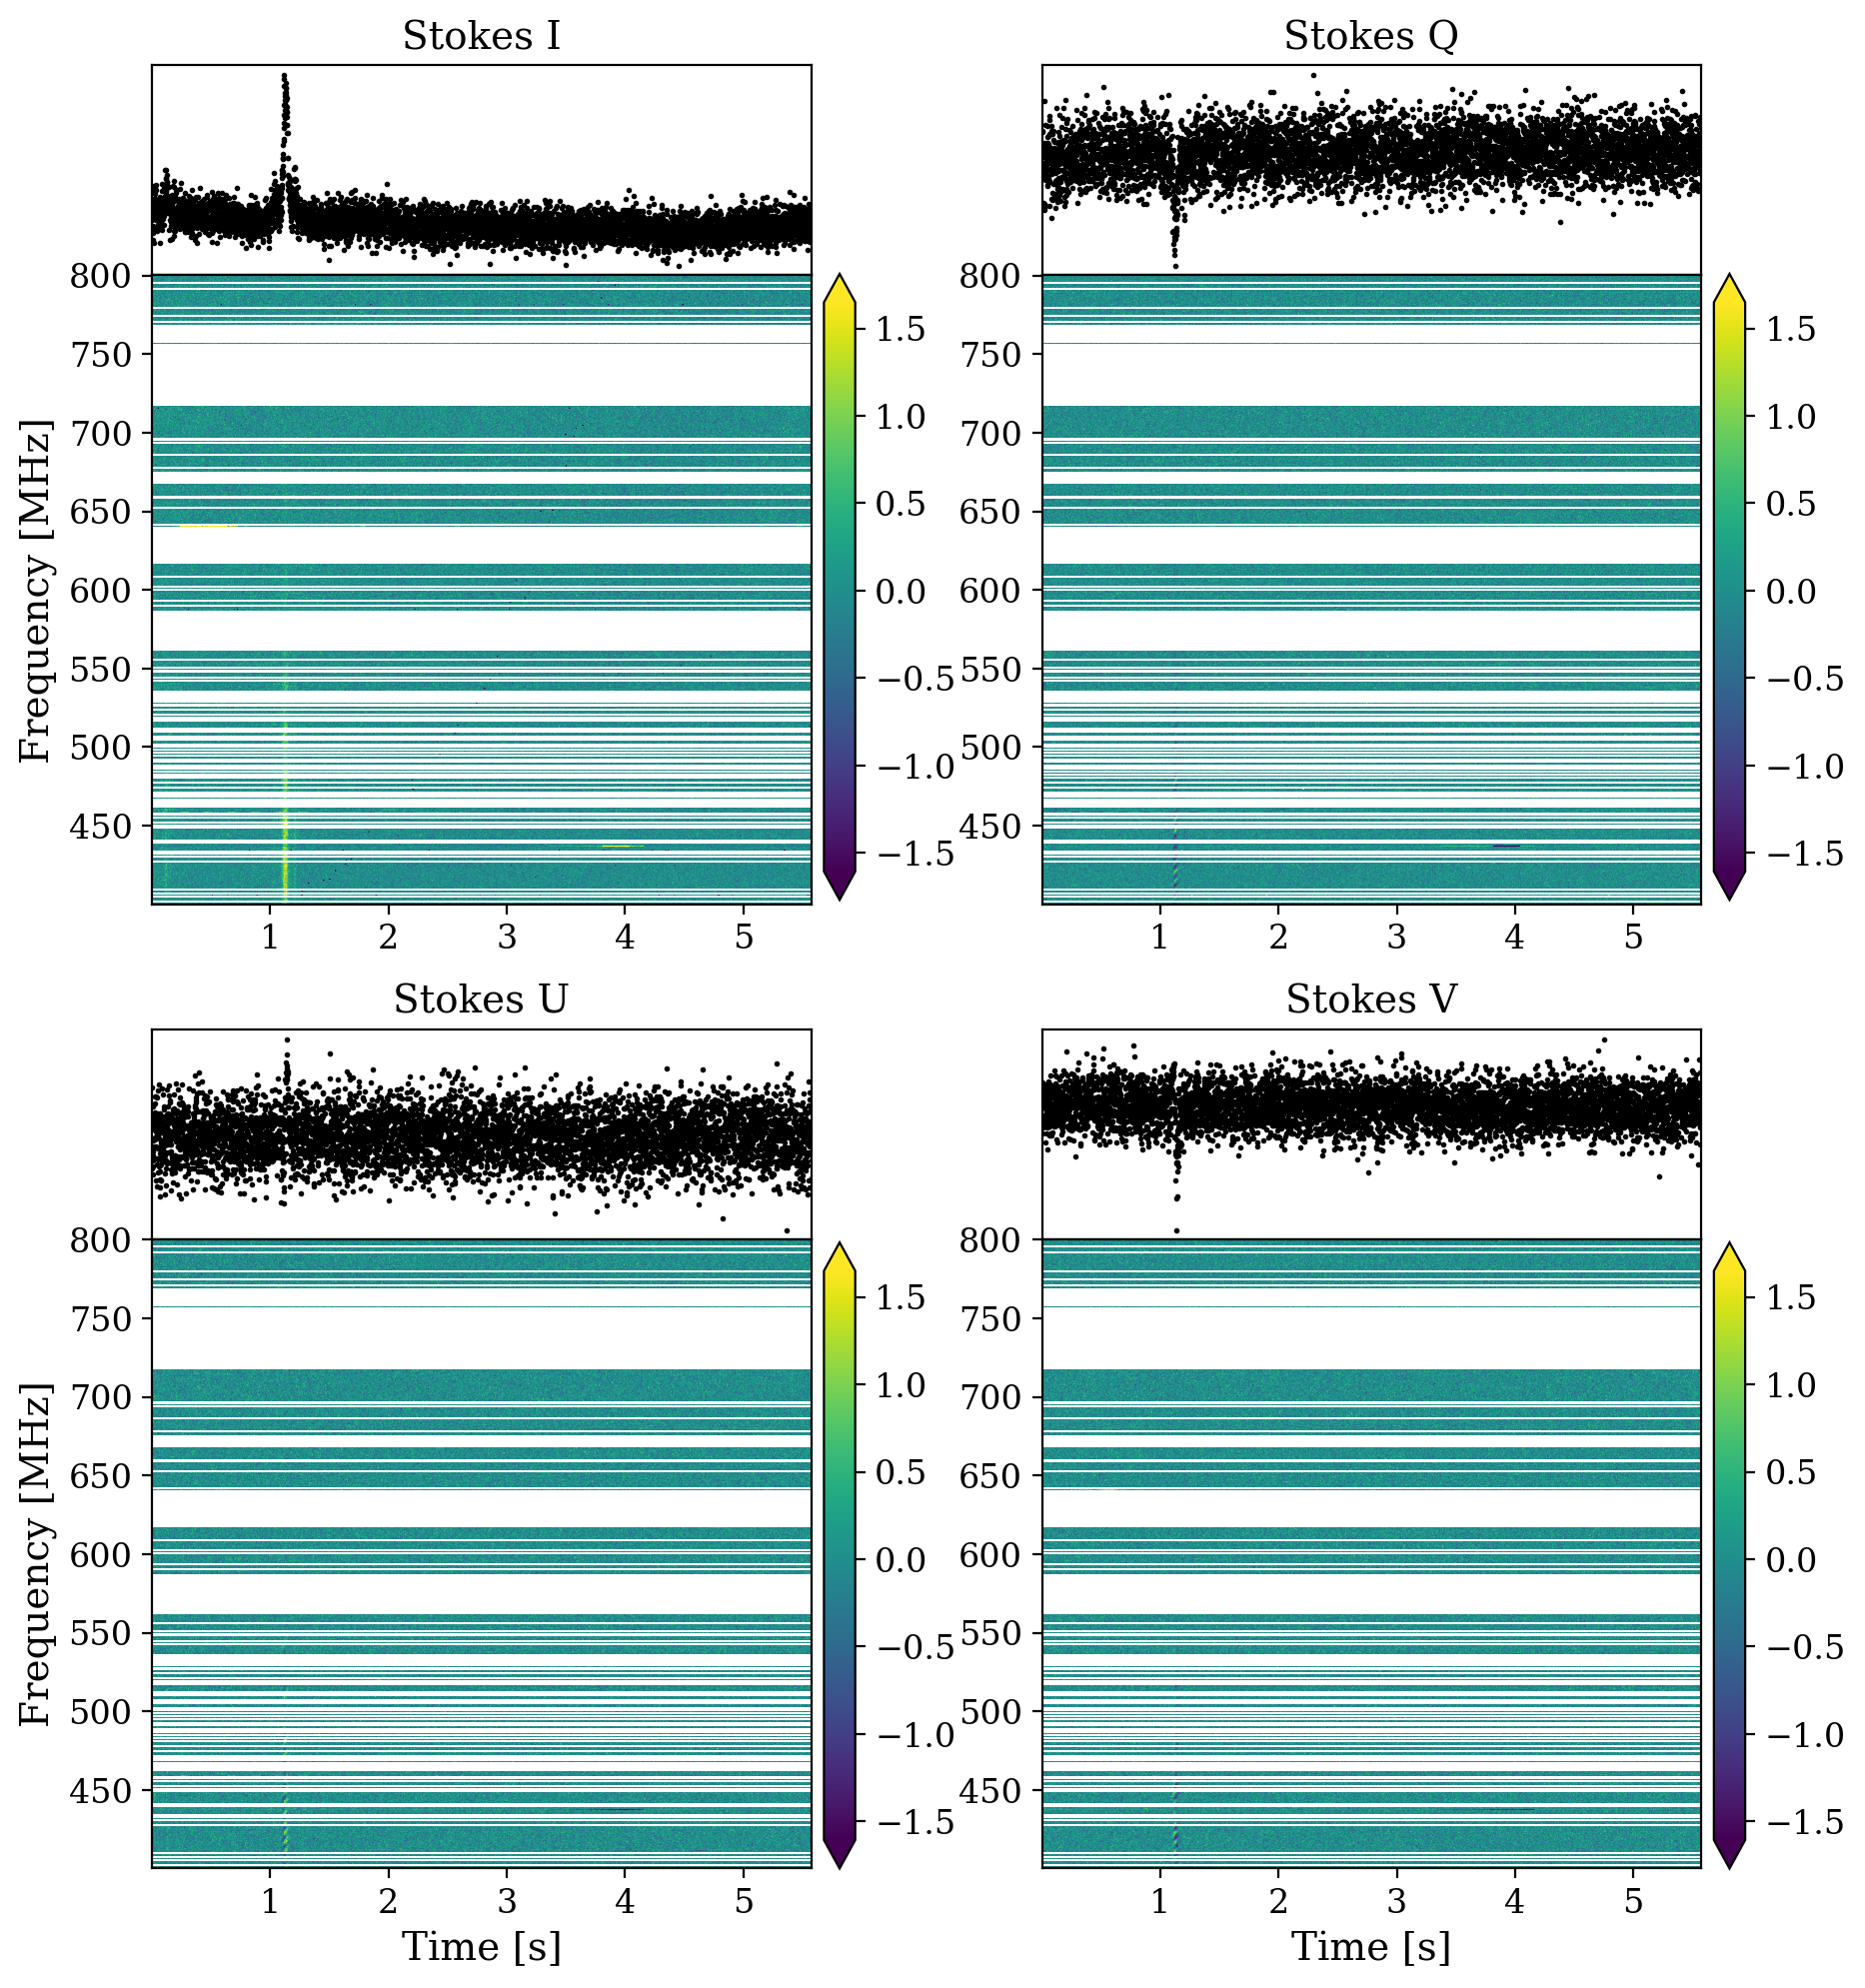

In [16]:
# Plot normalized & masked data
plot_stokes(stokes_norm_masked, freq=freq, time=time, t_unit='s')

# Slice data around burst

In [ ]:
# Find the highest burst
max_burst_t = time[np.argmax(np.nanmean(stokes_norm_masked[0], axis=1))]
tstart, tstop = max_burst_t - 0.1, max_burst_t + 0.1
tstart_ind, tstop_ind = np.argmin(abs(time-tstart)), np.argmin(abs(time-tstop))
stokes_burst = stokes_norm_masked.copy()[:,tstart_ind:tstop_ind]  # normalized + masked
time_burst = time.copy()[tstart_ind:tstop_ind]  # new time axis
plot_stokes(stokes_burst, freq=freq, time=time_burst, t_unit='s')

# get raw data
# raw_stokes_burst = full_stokes.copy()[:,tstart_ind:tstop_ind]  # raw data + masked 
# raw_stokes_burst[:,:,rfi_mask] = np.nan

In [ ]:
# # Get spectra
# tstart_ind = np.argmin(abs(time-2.11))
# tstop_ind = np.argmin(abs(time-2.14))

# Q_spec = np.nan_to_num(np.nanmean(stokes_norm_masked[1,tstart_ind:tstop_ind], axis=0), nan=0.0)
# U_spec = np.nan_to_num(np.nanmean(stokes_norm_masked[2,tstart_ind:tstop_ind], axis=0), nan=0.0)
# L_spec = np.sqrt(Q_spec**2 + U_spec**2)
# Q_spec_norm = Q_spec/L_spec
# U_spec_norm = U_spec/L_spec

# # Plot Q & U spectra
# fig,axes = plt.subplots(2, figsize=(20,8))
# # stokes Q
# axes[0].plot(freq, Q_spec)
# # axes[0].plot(freq, Q_spec_norm)
# axes[0].set_ylabel('Q/L')
# # stokes U
# axes[1].plot(freq, U_spec)
# # axes[1].plot(freq, U_spec_norm)
# axes[1].set_ylabel('U/L')
# axes[1].set_xlabel('Frequency [MHz]')

# for ax in axes:
#     ax.set_xlim(freq[0], freq[-1])
# plt.show()

# Testing: Removing Delay Between X and Y

In [ ]:
# def invert_delay(delay, freq, U, V):
#     # if no units given, assumes ns for delay and MHz for frequency
#     if not isinstance(delay, u.quantity.Quantity):
#         delay = delay * u.ns
#     if not isinstance(freq, u.quantity.Quantity):
#         freq = freq * u.MHz
    
#     arg = (2*np.pi * freq[None,:].to(1/u.s) * delay.to(u.s)).value  # x
#     U_no_delay = U*np.cos(arg) + V*np.sin(arg)  # U_no_delay = U'cosx + V'sinx
#     V_no_delay = -U*np.sin(arg) + V*np.cos(arg)  # V_no_delay = -U'sinx + V'cosx

#     return U_no_delay, V_no_delay

In [ ]:
# delay = -2 * u.ns
# U_nodelay, V_nodelay = invert_delay(delay, freq, stokes_burst[2], stokes_burst[3])

In [ ]:
# stokes_nodelay = np.array([stokes_burst[0], stokes_burst[1], U_nodelay, V_nodelay])
# plot_stokes(stokes_nodelay, freq=freq, time=time_burst, t_unit='s')

In [ ]:
# t_burst_start, t_burst_stop = 1.10, 1.15
# inds = [
#     np.argmin(abs(time_burst-t_burst_start)),
#     np.argmin(abs(time_burst-t_burst_stop))
# ]

# # get spectra
# stokes_spectra = np.nanmean(stokes_nodelay[:,inds[0]:inds[1]], axis=1)

# # plot
# plt.figure(figsize=(10,4))
# plt.plot(freq, stokes_spectra[2], ms=2, lw=1, label="U")
# plt.plot(freq, stokes_spectra[3], ms=2, lw=1, label="V")
# plt.xlabel("Frequency [MHz]")
# plt.xlim(400,525)
# plt.legend()
# plt.show()

# RM Synthesis

### RMSF

$$ R(\phi) = \frac{1}{W} \sum_j W_j e^{-2i\phi(\lambda_j^2)} $$

In [17]:
# Define weight function (with and without masked channels)
W_full = np.ones_like(freq)
W = W_full.copy()
W[rfi_mask] = 0  # Set bad channels to zero (rfi_masked_ch=True where masked)

# lambda^2 array
lambda2_array = (c.value/(freq*1e6))**2  # shape (Nfreqs)
l2_min = np.min(lambda2_array)
l2_max = np.max(lambda2_array)
dl2 = np.median(np.abs(np.diff(lambda2_array)))  # median of dl^2
Dl2 = l2_max - l2_min  # total range of lambda^2

# phi array
fwhm = 2 * np.sqrt(3) / Dl2  # FWHM of the RMSF
# phi_max = np.sqrt(3)/dl2  # max RM to search
# phi_max = 10 * fwhm  # ~10*FWHM
phi_max = 1500
dphi = 0.05 * fwhm  # spacing between phi values, ~0.1*FWHM
pos_phi_arr = np.arange(0, phi_max+dphi, dphi)
neg_phi_arr = np.flip(-pos_phi_arr[1:])
phi_array = np.concatenate([neg_phi_arr, pos_phi_arr])  # shape (N_phi,)
N_phi = len(phi_array)

In [18]:
# Compute FSF (RMSF) w/ masked channels
K = 1.0 / np.nansum(W)  # normalization constant
a = (-2.0 * 1j * phi_array).astype('complex64')  # exponent for RMSF
b = np.outer(a, lambda2_array)  # shape (Nphi, Nlambda2)
RMSF = K * np.sum(W * np.exp(b), 1)  # sum along lambda axis & normalize

# RMSF w/ all channels
K_full = 1.0 / np.sum(W_full)  # normalization constant
RMSF_full = K_full * np.sum(W_full * np.exp(b), 1)  # sum along lambda axis & normalize

In [ ]:
# Plot FSF
# plt.figure(figsize=(8, 5))
# plt.title('RMSF')

# plt.plot(phi_array, np.abs(RMSF), lw=1.2, label='w/ Masked Channels')
# plt.plot(phi_array, np.abs(RMSF_full), lw=1, alpha=0.5, c='k', label='All Channels')
# plt.xlim(-500,500)

# plt.xlabel(r'$\phi$ [rad/m$^2$]')
# plt.ylabel('Amplitude')
# plt.legend(loc='upper right')
# plt.show()

### RM Search

Functions

In [19]:
def invert_delay(delay, freq, U, V):
    # if no units given, assumes ns for delay and MHz for frequency
    if not isinstance(delay, u.quantity.Quantity):
        delay = delay * u.ns
    if not isinstance(freq, u.quantity.Quantity):
        freq = freq * u.MHz
    
    arg = (2*np.pi * freq[None,:].to(1/u.s) * delay.to(u.s)).value  # x
    U_no_delay = U*np.cos(arg) + V*np.sin(arg)  # U_no_delay = U'cosx + V'sinx
    V_no_delay = -U*np.sin(arg) + V*np.cos(arg)  # V_no_delay = -U'sinx + V'cosx

    return U_no_delay, V_no_delay


def get_spectra(Q, U, t_range=[0,None], freq=freq, f_range=[0,None], normalize=True, replace_nans=True):
    """
    Calculate (normalized) Q and U spectra.
    Returns normalized Q and U spectra averaged over the specified time range.

    Parameters
    ----------
    Q : Stokes Q array (shape: [Nfreqs, Ntimes]).
    U : Stokes U array (shape: [Nfreqs, Ntimes]).
    t_range : Time range to average over (in indices) [start, stop].
    freq : Frequency array (in MHz), matches Nfreqs.
    f_range : Frequency range to get the spectrum for (in indices) [start, stop].
    normalize : If True, normalize the spectra by L.
    replace_nans : If True, replace NaNs with 0 in the normalized spectra.
    """
    
    # Time average
    f_start, f_stop = f_range
    freq = freq[f_start:f_stop]
    t_start, t_stop = t_range
    Q_spec = np.nanmean((Q)[f_start:f_stop,t_start:t_stop], axis=1)
    U_spec = np.nanmean((U)[f_start:f_stop,t_start:t_stop], axis=1)

    # Normalize
    if normalize:
        L_spec = np.sqrt(Q_spec**2 + U_spec**2)
        Q_spec_norm = Q_spec / L_spec
        U_spec_norm = U_spec / L_spec
    else:
        Q_spec_norm = Q_spec
        U_spec_norm = U_spec

    # Handle NaNs
    if replace_nans:
        Q_spec_norm = np.nan_to_num(Q_spec_norm, nan=0.0)
        U_spec_norm = np.nan_to_num(U_spec_norm, nan=0.0)

    return Q_spec_norm, U_spec_norm



def rm_synthesis(P_spec, lambda_sq, phi_array):
    """
    Perform RM synthesis on the given P spectrum.
    
    Parameters
    ----------
    P_spec : Normalized complex P spectrum (shape: [Nfreqs,]).
    lambda_sq : Squared wavelength array (shape: [Nfreqs,]). In m^2.
    phi_array : Array of phi values to compute the FDF for (shape: [N_phi,]). In rad.

    Returns
    -------
    RM_meas : Phi value at which the peak of the FDF occurs (in rad/m^2).
    FDF : F(phi) for the given P_spec (shape: [N_phi,]).
    """

    # Compute FDF
    K = 1.0 / np.nansum(W)  # normalization constant
    a = (-2.0 * 1j * phi_array).astype('complex64')
    b = np.outer(a, lambda_sq)  # shape (Nphi, Nlambda2)
    FDF = K * np.sum(P_spec * np.exp(b), 1)  # sum along lambda axis & normalize

    # Find peak phi (= RM)
    FDF_peak_ind = np.argmax(np.abs(FDF))
    RM_meas = phi_array[FDF_peak_ind]

    return RM_meas, FDF

Run search

In [20]:
# time_rmsynth = time_burst.copy()
# stokes_rmsynth = stokes_burst.copy()
time_rmsynth = time.copy()
stokes_rmsynth = stokes_norm_masked.copy()

In [ ]:
# Cover a range of delays
dtau = 0.5
delay_arr = np.arange(-2.5, 2.5+dtau, dtau) * u.ns
fdf_delay_dict = {}

for tau in delay_arr:
    print(f"processing delay of {tau}")
    # Remove delay effects
    U_nodelay, V_nodelay = invert_delay(tau, freq, stokes_rmsynth[2], stokes_rmsynth[3])
    stokes_rmsynth = np.array([stokes_rmsynth[0], stokes_rmsynth[1], U_nodelay, V_nodelay])
    # plot_stokes(stokes_rmsynth, freq=freq, time=time_burst, t_unit='s')
    
    # Time slice parameters
    step = 1  # num of time channels to average over
    time_slice_arr = time_rmsynth[::step]  # New time array (using start times of each time slice)
    
    # Set up arrays for results
    RM_meas_arr = np.zeros(len(time_slice_arr))  # Store peak of FDF for each time slice
    FDF_arr = np.zeros((len(time_slice_arr), N_phi), dtype=complex)  # FDF for each time slice
    
    # Step through time & compute FDF
    for i,start_time in enumerate(time_slice_arr):
      # Time slice indices
      t_start_ind = np.argwhere(time_rmsynth==start_time)[0][0]
      t_stop_ind = t_start_ind+step
    
      # Get the spectra (avg over time slice)
      Q_spec_norm, U_spec_norm = get_spectra(stokes_rmsynth[1].T, stokes_rmsynth[2].T, t_range=[t_start_ind, t_stop_ind])
      P_spec_norm = Q_spec_norm + 1j*U_spec_norm
    
      # Compute FDF and RM for the time slice
      RM_meas_arr[i], FDF_arr[i] = rm_synthesis(P_spec_norm,
                                                lambda_sq=lambda2_array,
                                                phi_array=phi_array,
                                              )
    fdf_delay_dict[tau] = FDF_arr

### Using RM Tools

In [ ]:
# freq_Hz = (freq * u.MHz).to(u.Hz).value
# for i,t in enumerate(time_burst):
#     # Get data
#     d = raw_stokes_burst[:,i]  # shape (Nstokes, Nfreqs)
#     I, Q, U = d[:3]
#     errI = np.ones_like(freq_Hz) * 1e-3
#     errQ = np.ones_like(freq_Hz) * 1e-3
#     errU = np.ones_like(freq_Hz) * 1e-3

#     # save data in a .txt
#     data_to_save = np.column_stack([freq_Hz, I, Q, U, errI, errQ, errU])
#     save_loc = f"/scratch/abernier/rm-search-Bernier-2025/testing_rmtools/"
#     filename = f"synthesis_{t:.3f}.txt"    
#     full_path = save_loc + filename
#     np.savetxt(full_path, data_to_save, fmt="%.6e")               

#     # Run rm synthesis
#     RMsynth_1D_path = Path(RMtools_1D.__file__).parent / "do_RMsynth_1D.py"
#     flags = ["-p", "-v", "-S"]  # plot, verbose, save arrays
#     cmd = [sys.executable, str(RMsynth_1D_path), full_path] + flags  # Build shell command
#     subprocess.run(cmd)  # Run it
    
#     # delete .txt
#     os.remove(full_path)

# Plots

### FDF Imshow Plots

In [ ]:
def downsample_time_mean(data, factor):
    """
    Downsample data along the time axis by some factor (number of time bins per group)
    """
    # Trim time axis so it's divisible by 'factor'
    Ntime = data.shape[0]
    Ntime_trimmed = (Ntime // factor) * factor
    trimmed_data = data[:Ntime_trimmed]

    # Group consecutive time samples into bins of size 'factor'
    # New shape: (Ngroups, factor, Nphi)
    grouped_data = trimmed_data.reshape(-1, factor, data.shape[1])

    # Average within each group (collapse the 'factor' axis)
    downsampled_data = grouped_data.mean(axis=1)
    
    return downsampled_data
    

def plot_2panels(data, time, phi, downsamp_factor=8, cbar_label='', plot_true=False,
                 ax1_type='peak', ax2_ylabel=r'$\phi$ [rad/m$^2$]', t_unit='s',
                 xlim=None, ylim=None, suptitle=None):
    """
    Make a 2-panel phi/time plot of some data.

    Parameters
    ----------
    data : Data to plot (shape: [Ntimes, Nphi]). Absolute value is taken.
    time : Time array (shape: [Ntimes]).
    phi : Phi array (shape: [Nphi]).
    cbar_label : Colorbar label.
    plot_true : If True, plot the true burst times as vertical dashed lines.
    ax1_type : Type of the first panel ('peak' for peak amplitude, 'mean' for mean amplitude).
    t_unit : Unit for the time axis (e.g., 'ms', 's').
    """

    # Define figure with 2 rows, 3 columns
    fig = plt.figure(figsize=(8, 8), dpi=150)
    gs = gridspec.GridSpec(2, 3, 
                           height_ratios=[1, 3],
                           width_ratios=[4, 1.2, 0.2],  # main, slice panel, colorbar
                           hspace=0,
                           wspace=0.05)

    ax1 = fig.add_subplot(gs[0, 0])              # timeseries panel
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)  # main imshow
    ax3 = fig.add_subplot(gs[1, 1], sharey=ax2)  # slice panel
    cax = fig.add_subplot(gs[1, 2])              # colorbar axis

    # AX1: True bursts
    # if plot_true:
    #     ax1.axvline(TIME_TRUE[0], color='grey', linestyle='--', label='True bursts')
    #     ax1.axvline(TIME_TRUE[1], color='grey', linestyle='--')
    #     ax1.legend(loc='upper left')

    # AX1: Get peak (or avg) for each time slice
    peak = np.max(np.abs(data), axis=1) if ax1_type=='peak' else np.mean(np.abs(data), axis=1)
    ax1.plot(time, peak, lw=0.8, c='rebeccapurple')
    ax1_label = 'Peak Amp.' if ax1_type == 'peak' else 'Avg. Amp.'
    ax1.set_ylabel(ax1_label)

    # AX2: Plot data (imshow)
    extent = (time[0], time[-1], phi[0], phi[-1])
    im = ax2.imshow(np.abs(data).T,  # shape (Ntimes, Nphi).T
                    aspect='auto',
                    origin='lower',
                    extent=extent,
                    cmap='viridis'
                    )
    ax2.set_xlabel(f'Time [{t_unit}]')
    ax2.set_ylabel(ax2_ylabel)
    if xlim is not None:
        ax2.set_xlim(xlim)
    if ylim is not None:
        ax2.set_ylim(ylim)

    # AX3: downsampled slices (along time axis)
    downsampled_data = downsample_time_mean(data, factor=downsamp_factor)
    for d in downsampled_data:
        ax3.plot(abs(d), phi, color='k', alpha=0.1, lw=0.7)
    # ax3.set_xlabel('avg')
    ax3.set_title(f'Time-avg (×{downsamp_factor})')
    ax3.tick_params(labelleft=False)

	# Colorbar
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(cbar_label)
    
    if suptitle is not None:
        ax1.set_title(suptitle)
    plt.show()

In [ ]:
# --- Full FDF imshow plots ---
for tau in delay_arr:
    FDF = fdf_delay_dict[tau]
    plot_2panels(FDF, time_slice_arr, phi_array, cbar_label='Amplitude',
                 suptitle=f'FDF ({tau})')

### FDF delay panels

In [ ]:
# Get burst time range
t_burst_start, t_burst_stop = 1.10, 1.15
inds = [
    np.argmin(abs(time_slice_arr-t_burst_start)),
    np.argmin(abs(time_slice_arr-t_burst_stop))
]

In [ ]:
# --- FDF averaged over burst ---
Ndelay = len(delay_arr)
fig, axes = plt.subplots(
    Ndelay, 1,
    figsize=(8, 2 * Ndelay),
    dpi=150,
    sharex=True
)
if Ndelay == 1:
    axes = [axes]
cmap = plt.colormaps["tab20b"]
colors = [cmap(i / Ndelay) for i in range(Ndelay)]

for i, tau in enumerate(delay_arr):
    FDF = fdf_delay_dict[tau]
    fdf_slice = abs(np.nanmean(FDF[inds[0]:inds[1]], axis=0))
    axes[i].plot(phi_array, fdf_slice, lw=1, c=colors[i], label=f"{tau}")
    axes[i].legend(loc="upper right")
    axes[i].axvline(x=RM, label='True RM', c='dodgerblue', linestyle='--', alpha=0.6)
    axes[i].axvspan(-10, 10, alpha=0.5, color='lightgrey')

fig.supylabel("FDF Amplitude")
fig.supxlabel(r'$\phi$ [rad/m$^2$]')
plt.xlim(-500,500)
plt.tight_layout()
plt.show()

In [ ]:
# --- FDF averaged over burst + folding ---
Ndelay = len(delay_arr)
fig, axes = plt.subplots(
    Ndelay, 1,
    figsize=(8, 2 * Ndelay),
    dpi=200,
    sharex=True
)
if Ndelay == 1:
    axes = [axes]
cmap = plt.colormaps["tab20b"]
colors = [cmap(i / Ndelay) for i in range(Ndelay)]

for i, tau in enumerate(delay_arr):
    # Fold FDF
    FDF = fdf_delay_dict[tau]
    fdf_slice = abs(np.nanmean(FDF[inds[0]:inds[1]], axis=0))
    phi_zero_ind = np.argwhere(phi_array==0)[0,0]
    folded_phi = phi_array[phi_zero_ind:]
    pos_phi_fdf = fdf_slice[phi_zero_ind:]
    neg_phi_fdf = np.concatenate([[0], np.flip(fdf_slice[:phi_zero_ind])])
    folded_fdf = (pos_phi_fdf + neg_phi_fdf)  # using sum

    # FDF lines
    pos_line, = axes[i].plot(folded_phi, pos_phi_fdf, lw=1, ls=":", c="k", alpha=0.7, label=f"$+\phi$ range")  # positive phi
    neg_line, = axes[i].plot(folded_phi, neg_phi_fdf, lw=1, ls="--", c="k", alpha=0.7, label=f"$-\phi$ range")  # negative phi
    combined_line, = axes[i].plot(folded_phi, folded_fdf, lw=1, c=colors[i], label=f"{tau}")  # sum
    
    axes[i].legend(handles=[combined_line], loc="upper right")
    axes[i].axvline(x=abs(RM), label='True RM', c='dodgerblue', linestyle='--', alpha=0.6)
    axes[i].axvspan(-10, 10, alpha=0.5, color='lightgrey')

fig.legend(
    handles=[pos_line, neg_line],
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.013)
)
fig.supylabel("FDF Amplitude")
fig.supxlabel(r'|$\phi$| [rad/m$^2$]')
plt.xlim(0,500)
plt.tight_layout()
plt.show()

### Cross-Correlating

In [ ]:
# Cross-correlate measured FDF with FSF for each time slice
mode = 'full'
cross_corr_len = 2 * len(phi_array) - 1


# Compute over the range of delays
crosscorr_delay_dict = {}
for tau in delay_arr:
    print(f"processing delay of {tau}")
    FDF_arr = fdf_delay_dict[tau]
    
    # Compute cross-correlation for each time slice
    cross_corr_arr = np.zeros((len(time_slice_arr), cross_corr_len))  # shape (Ntimes, Nphi)
    for i,t in enumerate(time_slice_arr):
        # Get absolute value of FDF for the time slice
        fdf_slice = np.abs(FDF_arr[i])   
        # Cross-correlate with FSF
        cross_corr_arr[i] = correlate(fdf_slice, np.abs(RMSF), mode='full')
    
    crosscorr_delay_dict[tau] = cross_corr_arr


# Get channel lags and corresponding phi values
channel_lags = correlation_lags(len(phi_array), len(phi_array), mode='full')
phi_lags = channel_lags * dphi  # Convert channel lags to phi values

In [ ]:
# Plot
for tau in delay_arr:
    cross_corr = crosscorr_delay_dict[tau]
    plot_2panels(cross_corr, time_slice_arr, phi_lags, ax2_ylabel=r'$\phi$ [rad/m$^2$]', 
    			cbar_label='Amplitude', ax1_type='peak', suptitle=f'Cross-correlation ({tau})', 
                 downsamp_factor=8, ylim=(-1500,1500))

In [ ]:
for tau in delay_arr:
    cross_corr_arr = crosscorr_delay_dict[tau]

    # --- Plotting by slice ---
    plt.figure(figsize=(9, 6))
    plt.title(f'Cross-Correlation of FDF with RMSF ({tau})')
    
    # Downsample & plot data
    downsampled_cross_corr = downsample_time_mean(cross_corr_arr, factor=8)
    for i,d in enumerate(downsampled_cross_corr):
        plt.plot(phi_lags, abs(d), color="k", alpha=0.3, lw=0.7)
    plt.plot([], [], color='black', alpha=1, lw=1, label='FDFs')  # for slice label

    # Vertical lines
    plt.axvline(x=RM, label='True RM', 
                color='dodgerblue', linestyle='--', alpha=0.6)
    plt.axvline(x=0, color='grey', alpha=0.2)
    
    # Labels
    plt.xlabel(r'$\phi$ [rad/m$^2$]')
    plt.ylabel('Amplitude')

    # plot limits
    plt.xlim(-700, 700)
    ymin_ind = np.argmin(abs(phi_lags-700))
    ymin = np.min(abs(downsampled_cross_corr[:,ymin_ind]))
    ymax = np.max(abs(downsampled_cross_corr))
    plt.ylim(ymin-0.3, ymax + 0.3)
    
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.show()